# Smart Waste Classification — Exploratory Data Analysis

## Objective

The objective of this notebook is to inspect and understand the waste image dataset before developing machine-learning and deep-learning models.

The dataset contains five waste categories:

- Metal
- Plastic
- Paper
- Glass
- Organic

The EDA process will examine:

1. Dataset structure
2. Number of images per class
3. Class distribution
4. Image dimensions
5. Image readability and potential corrupted files
6. Representative images from each class
7. Dataset suitability for model development

No model training will be performed in this notebook. The purpose is to establish a reliable understanding of the data before preprocessing and model development.

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
DATA_DIR = Path("../data/raw")

print("Dataset path:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

Dataset path: ..\data\raw
Dataset exists: True


In [4]:
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print("Classes found:")
for class_name in classes:
    print("-", class_name)

Classes found:
- Glass
- Metal
- Organic
- Paper
- Plastic


## 2. Class Distribution

Before training a classifier, it is important to understand how many samples are available for each class.

A highly imbalanced dataset can cause a model to favour classes with more training examples. Therefore, class distribution will be examined before the train/validation/test split.

In [5]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_counts = {}

for class_name in classes:
    class_path = DATA_DIR / class_name
    
    count = sum(
        1 for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    )
    
    class_counts[class_name] = count

class_counts

{'Glass': 314, 'Metal': 375, 'Organic': 300, 'Paper': 323, 'Plastic': 335}

In [6]:
class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

class_distribution

,Class,Image Count
0,Glass,314
1,Metal,375
2,Organic,300
3,Paper,323
4,Plastic,335


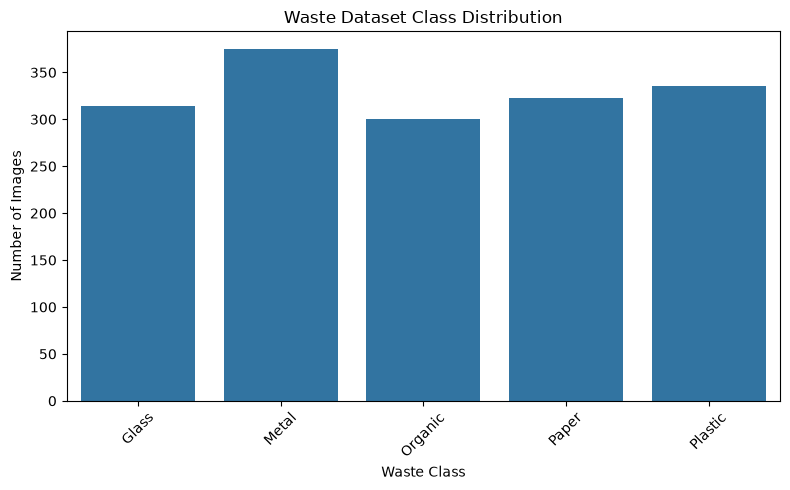

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=class_distribution,
    x="Class",
    y="Image Count"
)

plt.title("Waste Dataset Class Distribution")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
total_images = class_distribution["Image Count"].sum()

print("Total images:", total_images)

Total images: 1647


## 3. Image Dimensions

Image datasets can contain images with different resolutions and aspect ratios.

Understanding the original dimensions is important because the images will later need to be resized to a common input size before being passed to machine-learning and CNN models.

In [9]:
image_records = []

for class_name in classes:
    class_path = DATA_DIR / class_name
    
    for image_path in class_path.iterdir():
        if image_path.suffix.lower() not in image_extensions:
            continue
            
        image = cv2.imread(str(image_path))
        
        if image is not None:
            height, width, channels = image.shape
            
            image_records.append({
                "class": class_name,
                "filename": image_path.name,
                "width": width,
                "height": height,
                "channels": channels
            })

image_df = pd.DataFrame(image_records)

image_df.head()

,class,filename,width,height,channels
0,Glass,00000009-PHOTO-2025-10-31-11-19-18.jpg,1536,2048,3
1,Glass,00000010-PHOTO-2025-10-31-11-19-19.jpg,1536,2048,3
2,Glass,00000011-PHOTO-2025-10-31-11-19-19.jpg,1536,2048,3
3,Glass,00000013-PHOTO-2025-11-19-10-46-51.jpg,1536,2048,3
4,Glass,00000014-PHOTO-2025-11-19-10-46-51.jpg,1536,2048,3


In [10]:
image_df[["width", "height", "channels"]].describe()

,width,height,channels
count,1647.000000,1647.000000,1647.0
mean,1275.584092,1719.911354,3.0
std,465.411445,572.760266,0.0
min,126.000000,152.000000,3.0
25%,900.000000,1599.000000,3.0
50%,1200.000000,1600.000000,3.0
75%,1536.000000,2048.000000,3.0
max,4032.000000,4032.000000,3.0


## 4. Image Quality Check

OpenCV returns `None` when an image cannot be successfully decoded. These files should be identified before model training because corrupted images can cause training failures or reduce dataset reliability.

In [11]:
corrupted_images = []

for class_name in classes:
    class_path = DATA_DIR / class_name
    
    for image_path in class_path.iterdir():
        if image_path.suffix.lower() not in image_extensions:
            continue
        
        image = cv2.imread(str(image_path))
        
        if image is None:
            corrupted_images.append(str(image_path))

print("Corrupted/unreadable images:", len(corrupted_images))

if corrupted_images:
    print("\nFiles:")
    for image in corrupted_images:
        print(image)

Corrupted/unreadable images: 0


## 5. Sample Images

Representative images from each class are displayed to visually inspect the dataset and identify differences between waste categories.

In [12]:
classes

['Glass', 'Metal', 'Organic', 'Paper', 'Plastic']

In [16]:
for row, class_name in enumerate(classes):
    print(row, class_name)

0 Glass
1 Metal
2 Organic
3 Paper
4 Plastic


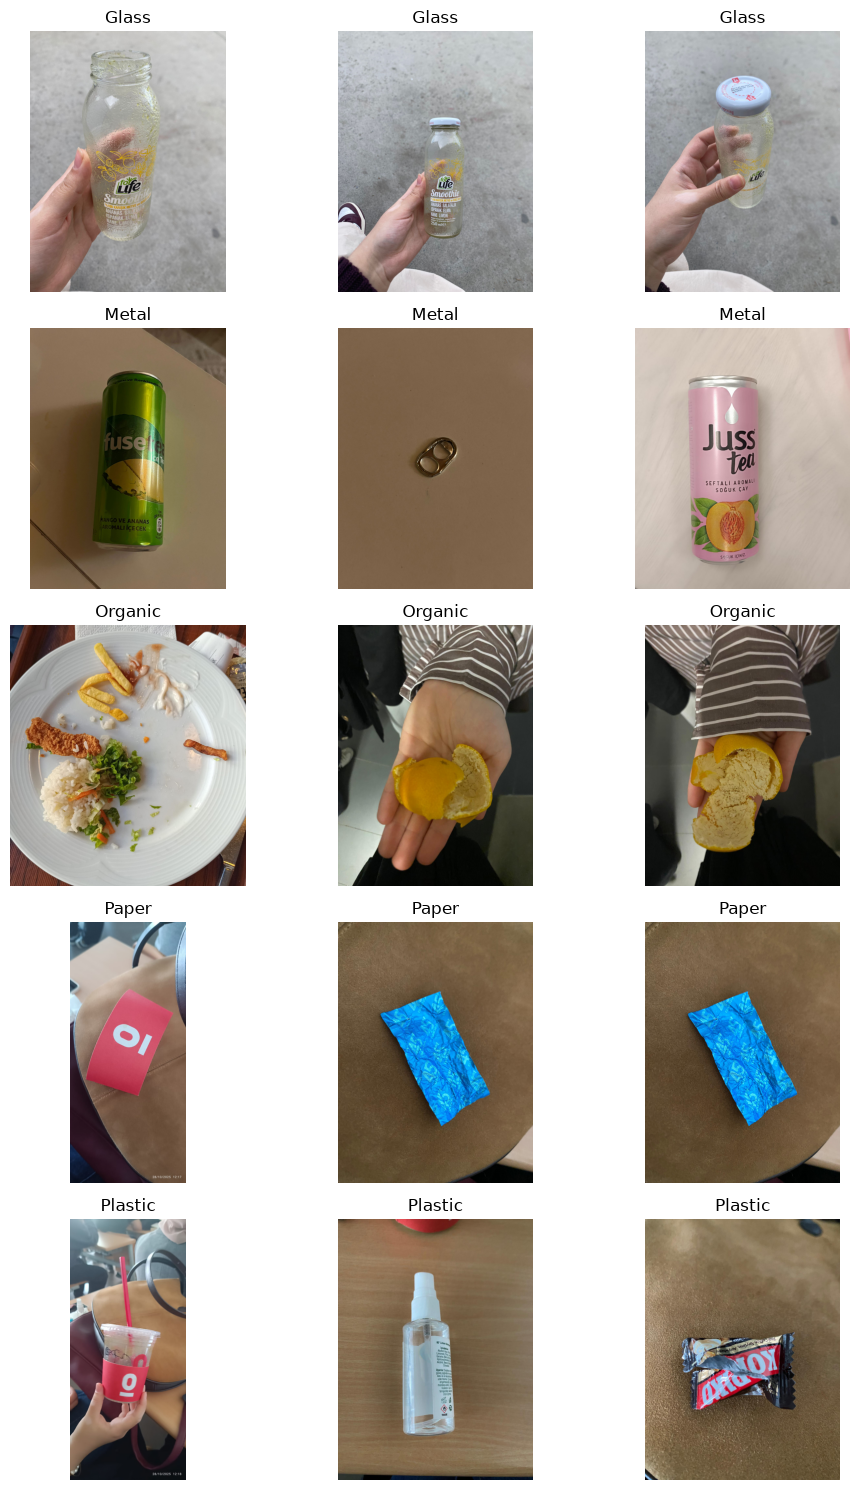

In [ ]:
fig, axes = plt.subplots(
    len(classes),
    3,
    figsize=(10, 3 * len(classes))
)

for row, class_name in enumerate(classes):
    class_path = DATA_DIR / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ][:3]
    
    for col, image_path in enumerate(image_files):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 6. Image Aspect Ratio Analysis

Image aspect ratio is examined because resizing images with significantly different aspect ratios can distort the visual features of waste objects.

The distribution of width-to-height ratios will help determine an appropriate resizing strategy for model development.

In [20]:
image_df["aspect_ratio"] = (
    image_df["width"] / image_df["height"]
)

image_df["aspect_ratio"].describe()

count    1647.000000
mean        0.775735
std         0.255887
min         0.404375
25%         0.562500
50%         0.750000
75%         0.750000
max         2.809524
Name: aspect_ratio, dtype: float64

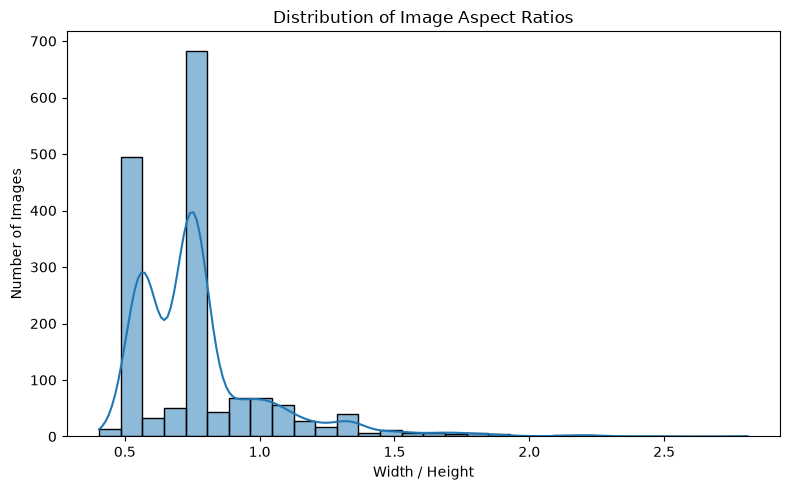

In [52]:
plt.figure(figsize=(8, 5))

sns.histplot(
    image_df["aspect_ratio"],
    bins=30,
    kde=True
)

plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [24]:
print("Smallest width:", image_df["width"].min())
print("Smallest height:", image_df["height"].min())

print("Largest width:", image_df["width"].max())
print("Largest height:", image_df["height"].max())

Smallest width: 126
Smallest height: 152
Largest width: 4032
Largest height: 4032


In [25]:
unusual_images = image_df[
    (image_df["width"] < 100) |
    (image_df["height"] < 100)
]

print("Images smaller than 100 pixels in either dimension:",
      len(unusual_images))

Images smaller than 100 pixels in either dimension: 0


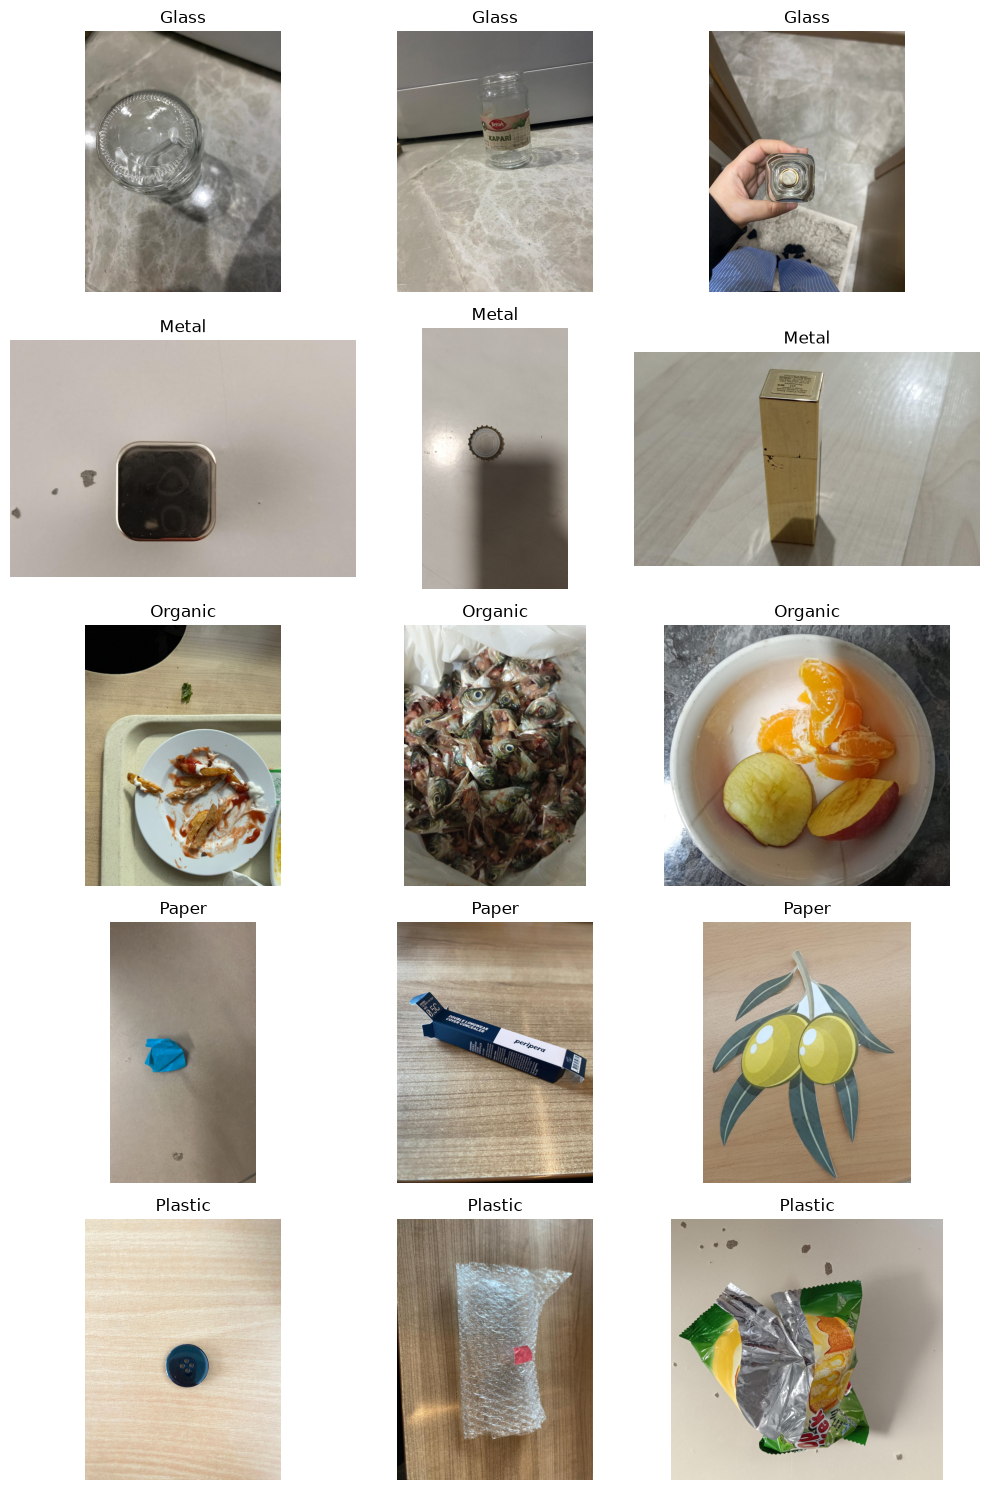

In [30]:
import random

fig, axes = plt.subplots(
    len(classes),
    3,
    figsize=(10, 15)
)

for row, class_name in enumerate(classes):

    class_path = DATA_DIR / class_name

    image_files = [
        file for file in class_path.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    selected_files = random.sample(
        image_files,
        min(3, len(image_files))  # min(3, len(image_files)) ensures we don't try to sample more images than available
    )

    for col, image_path in enumerate(selected_files):

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [31]:
duplicate_filenames = (
    image_df["filename"]
    .duplicated()
    .sum()
)

print("Duplicate filenames:", duplicate_filenames)

Duplicate filenames: 0


In [ ]:
import hashlib

image_hashes = []

for class_name in classes:

    class_path = DATA_DIR / class_name

    for image_path in class_path.iterdir():

        if image_path.suffix.lower() not in image_extensions:
            continue

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest() #This computes the MD5 hash of the file's content, which can be used to identify duplicate images based on their content rather than just their filenames.
        # hexdigest is a method that returns the hash value as a hexadecimal string, which is a common way to represent hash values in a readable format.
        # hashlib.md5() creates a new md5 hash object, and f.read() reads the entire content of the file in binary mode. 
        # hashlib is a built-in Python library that provides various hashing algorithms, including MD5, SHA-1, and SHA-256. In this case, we are using MD5 to generate a unique hash for each image file based on its content.
        
        image_hashes.append({
            "class": class_name,
            "filename": image_path.name,
            "hash": file_hash
        })

hash_df = pd.DataFrame(image_hashes)

In [33]:
hash_df

,class,filename,hash
0,Glass,00000009-PHOTO-2025-10-31-11-19-18.jpg,51a7ad718a9058bf7769d1696a1f0a62
1,Glass,00000010-PHOTO-2025-10-31-11-19-19.jpg,5786a74077d7c9f4a949b8b8bdc993fd
2,Glass,00000011-PHOTO-2025-10-31-11-19-19.jpg,c67d3ee753849c533ed4fbefb4598cb1
3,Glass,00000013-PHOTO-2025-11-19-10-46-51.jpg,e6a4fbe1b78a0e21592981f7a28a8860
4,Glass,00000014-PHOTO-2025-11-19-10-46-51.jpg,2269f72f5892712b9d1ca289eca4e53d
...,...,...,...
1642,Plastic,00000365-PHOTO-2025-12-04-12-14-20.jpg,02d0c286fbf2df8255bd85272443dff6
1643,Plastic,00000366-PHOTO-2025-12-04-12-14-34.jpg,80bc6227778a246d99f6395feba5e475
1644,Plastic,00000368-PHOTO-2025-12-04-12-15-00.jpg,801dcac8ba08fc994e714b2b5381918e
1645,Plastic,00000369-PHOTO-2025-12-04-12-18-00.jpg,001446a8df6c298af41d75771fbcb754


In [36]:
duplicate_hashes = hash_df[
    hash_df["hash"].duplicated(keep=False)
]

print("Number of images involved in exact duplicate groups:",
      len(duplicate_hashes))

Number of images involved in exact duplicate groups: 10


## 8. Duplicate Image Investigation

Exact duplicate images can cause data leakage if identical images are distributed across different dataset partitions.

Therefore, duplicate image hashes are examined before creating the train, validation, and test splits.

The objective is to determine:

1. Which images are duplicated.
2. How many unique duplicate groups exist.
3. Whether duplicates occur within the same class.
4. Whether any identical image appears under different class labels.

Duplicate groups will be handled before dataset splitting.

In [38]:
duplicate_groups = (
    hash_df[hash_df["hash"].duplicated(keep=False)]
    .sort_values("hash")
)

duplicate_groups

,class,filename,hash
1163,Paper,00000201-PHOTO-2025-12-02-18-31-32.jpg,2a54bdcce77638fbca8c0a9b01acc1e2
1178,Paper,00000216-PHOTO-2025-12-02-18-32-09.jpg,2a54bdcce77638fbca8c0a9b01acc1e2
1,Glass,00000010-PHOTO-2025-10-31-11-19-19.jpg,5786a74077d7c9f4a949b8b8bdc993fd
323,Metal,00000017-PHOTO-2025-10-31-11-19-07.jpg,5786a74077d7c9f4a949b8b8bdc993fd
1170,Paper,00000208-PHOTO-2025-12-02-18-31-32.jpg,aba34310dbcdb3696969703d0d4300b0
1179,Paper,00000217-PHOTO-2025-12-02-18-32-09.jpg,aba34310dbcdb3696969703d0d4300b0
2,Glass,00000011-PHOTO-2025-10-31-11-19-19.jpg,c67d3ee753849c533ed4fbefb4598cb1
322,Metal,00000016-PHOTO-2025-10-31-11-19-07.jpg,c67d3ee753849c533ed4fbefb4598cb1
1173,Paper,00000211-PHOTO-2025-12-02-18-31-32.jpg,d628592dd46fab5850457da11dc44a03
1180,Paper,00000218-PHOTO-2025-12-02-18-32-09.jpg,d628592dd46fab5850457da11dc44a03


In [39]:
duplicate_summary = (
    duplicate_groups
    .groupby("hash")
    .agg(
        image_count=("filename", "count"),
        classes=("class", lambda x: ", ".join(sorted(x.unique()))),
        filenames=("filename", lambda x: ", ".join(x))
    )
    .reset_index()
)

duplicate_summary

,hash,image_count,classes,filenames
0,2a54bdcce77638fbca8c0a9b01acc1e2,2,Paper,"00000201-PHOTO-2025-12-02-18-31-32.jpg, 000002..."
1,5786a74077d7c9f4a949b8b8bdc993fd,2,"Glass, Metal","00000010-PHOTO-2025-10-31-11-19-19.jpg, 000000..."
2,aba34310dbcdb3696969703d0d4300b0,2,Paper,"00000208-PHOTO-2025-12-02-18-31-32.jpg, 000002..."
3,c67d3ee753849c533ed4fbefb4598cb1,2,"Glass, Metal","00000011-PHOTO-2025-10-31-11-19-19.jpg, 000000..."
4,d628592dd46fab5850457da11dc44a03,2,Paper,"00000211-PHOTO-2025-12-02-18-31-32.jpg, 000002..."


In [49]:
print("Number of duplicate groups:", duplicate_summary.shape[0])
print("Total images involved:", duplicate_groups.shape[0])

Number of duplicate groups: 5
Total images involved: 10


In [50]:
cross_class_duplicates = duplicate_summary[
    duplicate_summary["classes"].str.contains(",")
]

print(
    "Duplicate groups appearing across multiple classes:",
    len(cross_class_duplicates)
)

cross_class_duplicates

Duplicate groups appearing across multiple classes: 2


,hash,image_count,classes,filenames
1,5786a74077d7c9f4a949b8b8bdc993fd,2,"Glass, Metal","00000010-PHOTO-2025-10-31-11-19-19.jpg, 000000..."
3,c67d3ee753849c533ed4fbefb4598cb1,2,"Glass, Metal","00000011-PHOTO-2025-10-31-11-19-19.jpg, 000000..."


## EDA Finding: Image Aspect Ratios

The dataset contains images with substantially different aspect ratios. The mean aspect ratio is 0.776, while the median is 0.750. The observed range is 0.404 to 2.810.

Most images are portrait-oriented, although a smaller number of images have wider aspect ratios.

This variation means that directly resizing all images to a square input size could distort the visual representation of waste objects. Therefore, the preprocessing pipeline will preserve the original aspect ratio during resizing and use padding to produce a consistent square input for the neural network.

This approach is intended to reduce geometric distortion while still providing a fixed-size input required by the CNN.

In [53]:
cross_class_hashes = set(cross_class_duplicates["hash"])

cross_class_files = []

for class_name in classes:
    class_path = DATA_DIR / class_name

    for image_path in class_path.iterdir():
        if image_path.suffix.lower() not in image_extensions:
            continue

        with open(image_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in cross_class_hashes:
            cross_class_files.append({
                "class": class_name,
                "filename": image_path.name,
                "path": str(image_path),
                "hash": file_hash
            })

cross_class_files_df = pd.DataFrame(cross_class_files)

cross_class_files_df

,class,filename,path,hash
0,Glass,00000010-PHOTO-2025-10-31-11-19-19.jpg,..\data\raw\Glass\00000010-PHOTO-2025-10-31-11...,5786a74077d7c9f4a949b8b8bdc993fd
1,Glass,00000011-PHOTO-2025-10-31-11-19-19.jpg,..\data\raw\Glass\00000011-PHOTO-2025-10-31-11...,c67d3ee753849c533ed4fbefb4598cb1
2,Metal,00000016-PHOTO-2025-10-31-11-19-07.jpg,..\data\raw\Metal\00000016-PHOTO-2025-10-31-11...,c67d3ee753849c533ed4fbefb4598cb1
3,Metal,00000017-PHOTO-2025-10-31-11-19-07.jpg,..\data\raw\Metal\00000017-PHOTO-2025-10-31-11...,5786a74077d7c9f4a949b8b8bdc993fd


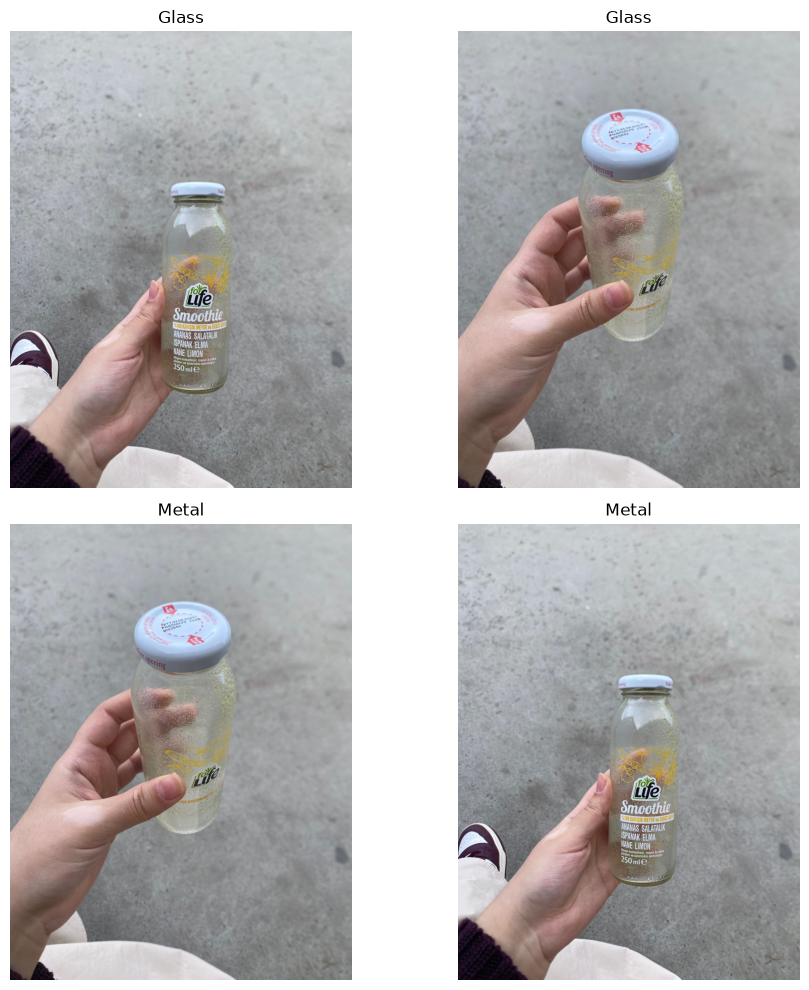

In [54]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10)
)

for ax, (_, row) in zip(
    axes.ravel(),
    cross_class_files_df.iterrows()
):
    image = cv2.imread(row["path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(row["class"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Duplicate and Label-Consistency Findings

Exact duplicate analysis identified five duplicate groups involving ten image files.

Three duplicate groups contained identical images assigned to the same `Paper` class. These duplicates do not provide additional independent information and therefore one copy from each group will be excluded from the modeling dataset.

Two duplicate groups contained identical images assigned to both `Glass` and `Metal`. Visual inspection showed that these images depict the same glass smoothie bottle, making the `Metal` label inconsistent with the primary waste material represented in the image.

To avoid introducing label assumptions and to prevent data leakage, all four images involved in the cross-class duplicate groups will be excluded from the modeling dataset.

After duplicate handling, the expected modeling dataset will contain 1,640 images.

The original dataset files will not be modified. Instead, excluded samples will be tracked programmatically so that the preprocessing procedure remains reproducible.

In [61]:
for hash_value, group in hash_df.groupby("hash"):
    print(hash_value, "\n", group)

001446a8df6c298af41d75771fbcb754 
         class                                filename  \
1645  Plastic  00000369-PHOTO-2025-12-04-12-18-00.jpg   

                                  hash  
1645  001446a8df6c298af41d75771fbcb754  
0021ca335abc0b4553bc0b261614b5c9 
      class                                filename  \
134  Glass  00000158-PHOTO-2025-12-07-18-56-01.jpg   

                                 hash  
134  0021ca335abc0b4553bc0b261614b5c9  
0025df74a488932f994006ebd1105ef0 
        class                                filename  \
718  Organic  00000058-PHOTO-2025-11-30-23-24-47.jpg   

                                 hash  
718  0025df74a488932f994006ebd1105ef0  
0026355f1de511c908a1a467c371a4d8 
        class                                filename  \
911  Organic  00000277-PHOTO-2025-12-10-12-12-41.jpg   

                                 hash  
911  0026355f1de511c908a1a467c371a4d8  
002c6b07edb53bab04782d74c4fbad31 
        class                                filename 

In [80]:
len(clean_df)

1640

In [78]:
clean_df = hash_df[
    ~hash_df["hash"].isin(cross_class_duplicates["hash"])
].drop_duplicates(
    subset=["class", "hash"],
    keep="first"
)

In [79]:
clean_df['class'].value_counts()

class
Metal      373
Plastic    335
Paper      320
Glass      312
Organic    300
Name: count, dtype: int64

In [81]:
clean_df.to_csv("../data/clean_dataset.csv", index=False)